In [54]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from chicago_housing import config as C
from chicago_housing.data.load import load_training_data
from chicago_housing.data import clean
from chicago_housing.features.spatial import add_distance_to_loop

pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
# Load only the columns the analysis needs (the file is 201 cols wide)
df = load_training_data(columns=C.analysis_columns())
print(df.shape)
df.head(3)

(413289, 40)


,meta_sale_price,loc_property_city,meta_modeling_group,meta_year,ind_pin_is_multicard,ind_pin_is_prorated,sv_outlier_reason1,sv_outlier_reason2,sv_outlier_reason3,meta_sale_seller_name,...,acs5_percent_household_owner_occupied,meta_pin,meta_nbhd_code,loc_census_tract_geoid,loc_latitude,loc_longitude,loc_x_3435,loc_y_3435,loc_chicago_community_area_name,loc_property_address
0,"369,000.000",BUFFALO GROVE,SF,2022,False,False,Statistical Anomaly,NaN,NaN,KATHRYN PARKS,...,0.963,03052140140000,38012,17031803010,42.149,-87.975,"1,081,376.631","1,997,097.573",NaN,276 CHERRYWOOD RD
1,"350,000.000",PALATINE,SF,2022,False,False,Non-person sale,NaN,NaN,"TIMOTHY J. DUNLAVY, SUCCESSOR TRUSTEE OF THE J...",...,0.835,02272000510000,29080,17031804106,42.095,-88.046,"1,062,288.033","1,977,170.215",NaN,877 S BROCKWAY ST
2,"706,555.000",PALATINE,SF,2022,False,False,Statistical Anomaly,NaN,NaN,LAWRENCE A. SALANI,...,0.835,02272000700000,29080,17031804106,42.092,-88.045,"1,062,472.146","1,976,420.902",NaN,54 ALDRIDGE AVE


## 1. Scope filters
Countywide + all-types + 9-years  ->  Chicago / single-family / 2022-24 / single-card.
This also removes the bulk of the missingness (community area & ward only populate in-city).

In [56]:
# Appy filters for the city, single family and years
scoped = clean.scope_filter(df)

# confirm the filters landed as expected
print(scoped[C.YEAR_COL].value_counts().sort_index())
print(scoped[C.MODELING_GROUP_COL].value_counts())

scope_filter:         413,289 ->   33,106 rows
meta_year
2022    12909
2023    10546
2024     9651
Name: count, dtype: int64
meta_modeling_group
SF    33106
BB        0
MF        0
Name: count, dtype: int64


In [47]:
scoped.loc[scoped['sv_outlier_reason1']=='Non-person sale'][[
    'loc_property_address',
    'meta_sale_price',
    'meta_year',
    'meta_sale_seller_name',
    'meta_sale_buyer_name',
    'loc_chicago_community_area_name',
    "sv_outlier_reason1", 
    "sv_outlier_reason2", 
    "sv_outlier_reason3"
    ]].sort_values(by='meta_sale_price',ascending=False).head(30)

,loc_property_address,meta_sale_price,meta_year,meta_sale_seller_name,meta_sale_buyer_name,loc_chicago_community_area_name,sv_outlier_reason1,sv_outlier_reason2,sv_outlier_reason3
173773,15 W BURTON PL,"8,000,000.000",2022,CHICAGO TITLE LAND TRUST COMPANY AS TRUSTEE UN...,THE JAZZ TRUST U/T/D 05/16/2005,NEAR NORTH SIDE,Non-person sale,Statistical Anomaly,NaN
31601,54 E SCOTT ST,"6,500,000.000",2023,"SCOTT STREET PARTNERS, LLC",CHICAGO TITLE LAND TRUST COMPANY,NEAR NORTH SIDE,Non-person sale,Statistical Anomaly,NaN
286887,1849 N BURLING ST,"5,800,000.000",2022,"CHICAGO TITLE LAND TRUST COMPANY, AS TRUSTEE U...",CHICAGO TITLE LAND TRUST COMPANY AS TRUSTEE UN...,LINCOLN PARK,Non-person sale,Statistical Anomaly,NaN
306110,1935 N BURLING ST HSE,"5,700,000.000",2022,DANIEL J. O'CONNOR,1935 BURLING TRUST,LINCOLN PARK,Non-person sale,Statistical Anomaly,NaN
87413,1401 N DEARBORN ST,"5,650,000.000",2023,"CHICAGO TITLE LAND TRUST COMPANY, AS TRUSTEE O...","ROSEWOOD RESIDENTIAL, LLC",NEAR NORTH SIDE,Non-person sale,Statistical Anomaly,NaN
146168,1837 N ORCHARD ST,"5,650,000.000",2022,"MICHAEL P. WALSH, AS TRUSTEE OF THE MICHAEL P....","STEPHANIE ANDERSEN-FORMOLO, AS TRUSTEE OF THE ...",LINCOLN PARK,Non-person sale,Statistical Anomaly,NaN
13984,1248 N ASTOR ST,"5,600,000.000",2022,"1248 ASTOR, LLC",ETAI TIMNA,NEAR NORTH SIDE,Non-person sale,Statistical Anomaly,NaN
395869,21 E CEDAR ST,"5,100,000.000",2023,"STEVEN M KAPLAN, TRUSTEE OF THE STEVEN M KAPLA...",CHICAGO TITLE LAND TRUST COMPANY AS TRUSTEE UN...,NEAR NORTH SIDE,Non-person sale,Statistical Anomaly,NaN
288008,105 E BELLEVUE PL,"4,900,000.000",2024,ROBERT JEROME MELMAN,KRISTINE SUSAN CHEREK AS TRUSTEE OF THE KRISTI...,NEAR NORTH SIDE,Non-person sale,Statistical Anomaly,NaN
35488,1924 N BURLING ST,"4,850,000.000",2022,ARIN CHILCOTE,"CHICAGO TITLE LAND TRUST, AN ILLINOIS CORPORAT...",LINCOLN PARK,Non-person sale,Statistical Anomaly,NaN


## 2. Sale validity — inspect the reasons BEFORE deciding what to drop
`sv_is_outlier` bundles *non-market transfers* (drop — different data-generating process) with 
*price-extreme but genuine* sales (keep for inference). Read the reason columns and calibrate 
`config.NON_ARMS_LENGTH_REASONS` to match the actual category strings printed below.

In [57]:
for col in C.SV_REASON_COLS:
    print(f'\n=== {col} ===')
    print(scoped[col].value_counts(dropna=True))


=== sv_outlier_reason1 ===
sv_outlier_reason1
Non-person sale               10527
Statistical Anomaly            5625
Short-term owner               2769
PTAX-203 Exclusion             1243
Low price                      1091
High price                      275
Family Sale                     206
Low price per square foot       194
High price per square foot      153
Name: count, dtype: int64

=== sv_outlier_reason2 ===
sv_outlier_reason2
Non-person sale               3360
Statistical Anomaly           2431
Low price per square foot      893
High price per square foot     140
Short-term owner                62
Family Sale                     46
PTAX-203 Exclusion              13
Raw price threshold              1
Low price                        1
Name: count, dtype: int64

=== sv_outlier_reason3 ===
sv_outlier_reason3
Non-person sale              519
Statistical Anomaly          445
PTAX-203 Exclusion           264
Short-term owner              50
Family Sale                    8
Pri

In [58]:
# Apply the split: drop non-arm's-length, keep price-extreme
scoped_valid = clean.drop_non_market(scoped)

drop_non_market: 33,106 -> 30,693
  always (PTAX/family):   1,747
  below $10,000 floor:  0
  entity + nominal/low:   670
  land-trust/title kept (market price): 1,247


## MD File to capture reasoning behind inclusion / exclusion of sale price logic

## 3. Column profile — missingness + degeneracy
A column can be 0% missing yet useless (one value in >95% of rows). `pct_modal` catches that.

In [13]:
candidate = (
    C.BLOCK_A_STRUCTURE
    + [c for c in C.BLOCK_B_LOCATION if c != 'dist_to_loop_ft']
    + C.DEMOGRAPHICS
)
prof = clean.profile_columns(scoped_valid, candidate)

(C.OUTPUTS / 'tables').mkdir(parents=True, exist_ok=True)
prof.to_csv(C.OUTPUTS / 'tables' / 'step0a_profile.csv', index=False)
prof

,column,role,dtype,pct_missing,n_unique,pct_modal,modal_value
0,acs5_median_income_household_past_year,acs5,float64,0.008,1367,0.005,"137,043.000"
1,acs5_percent_education_bachelor,acs5,float64,0.000,1402,0.005,0.367
2,acs5_percent_household_owner_occupied,acs5,float64,0.000,1404,0.005,0.926
3,char_porch,char,category,0.001,3,0.792,0
4,char_bldg_sf,char,float64,0.000,2586,0.009,"1,040.000"
5,char_land_sf,char,float64,0.000,3452,0.091,"3,750.000"
6,char_yrblt,char,float64,0.000,161,0.030,"1,923.000"
7,char_beds,char,float64,0.000,9,0.495,3.000
8,char_fbath,char,float64,0.000,8,0.645,1.000
9,char_gar1_size,char,category,0.000,8,0.550,3


## 4. Build the analytic sample + engineered feature
`build_analytic_sample` runs the canonical pipeline (scope -> validity -> log target). 
Then we add `dist_to_loop_ft` (our monocentric differentiator).

In [14]:
sample = clean.build_analytic_sample(df)
sample = add_distance_to_loop(sample)
print('final analytic sample:', sample.shape)

scope_filter:         413,289 ->   33,106 rows
drop_non_arms_length:  33,106 ->   18,438 rows (14,668 non-market removed)
analytic sample:                18,438 rows
final analytic sample: (18438, 39)


## 5. Distributions
### 5.1 Target — why we log

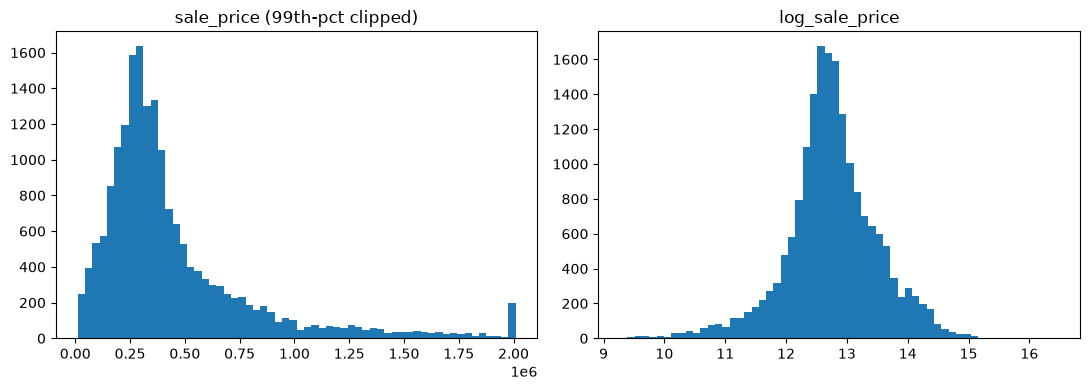

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(sample[C.TARGET_RAW].clip(upper=sample[C.TARGET_RAW].quantile(0.99)), bins=60)
axes[0].set_title('sale_price (99th-pct clipped)')
axes[1].hist(sample[C.TARGET], bins=60)
axes[1].set_title('log_sale_price')
plt.tight_layout(); plt.show()

### 5.2 Key predictors

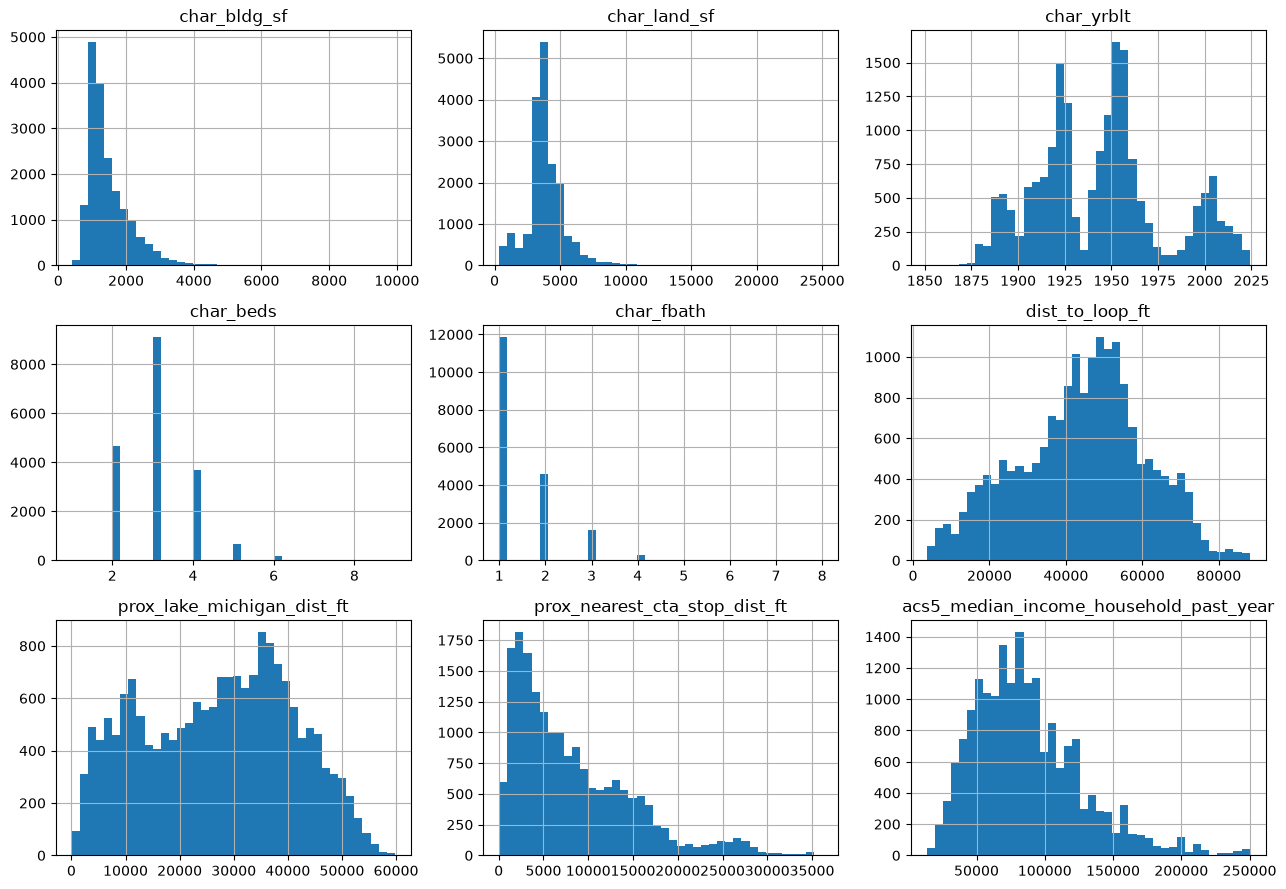

In [16]:
numeric = [
    'char_bldg_sf', 'char_land_sf', 'char_yrblt', 'char_beds', 'char_fbath',
    'dist_to_loop_ft', 'prox_lake_michigan_dist_ft', 'prox_nearest_cta_stop_dist_ft',
    'acs5_median_income_household_past_year',
]
sample[numeric].hist(bins=40, figsize=(13, 9))
plt.tight_layout(); plt.show()

## 6. Outlier / sanity analysis
Two things: (a) a price-per-sqft sanity pass, (b) impossible-value checks. 
Remember we *retained* price-extreme sales on purpose — this is about spotting **data errors**, 
not trimming genuine tails.

In [17]:
sample['price_per_sqft'] = sample[C.TARGET_RAW] / sample['char_bldg_sf'].replace(0, np.nan)
sample['price_per_sqft'].describe(percentiles=[.01, .05, .5, .95, .99])

count   18,436.000
mean       291.512
std        150.222
min          6.234
1%          32.678
5%          85.002
50%        271.806
95%        575.090
99%        752.268
max      2,132.353
Name: price_per_sqft, dtype: float64

In [18]:
checks = {
    'sale_price <= 10k':   int((pd.to_numeric(sample[C.TARGET_RAW]) <= 10_000).sum()),
    'char_bldg_sf <= 0':   int((sample['char_bldg_sf'] <= 0).sum()),
    'char_beds == 0':      int((sample['char_beds'] == 0).sum()),
    'char_yrblt < 1850':   int((sample['char_yrblt'] < 1850).sum()),
    'price_per_sqft > 2000': int((sample['price_per_sqft'] > 2000).sum()),
}
pd.Series(checks, name='n_rows')

sale_price <= 10k        0
char_bldg_sf <= 0        0
char_beds == 0           0
char_yrblt < 1850        0
price_per_sqft > 2000    1
Name: n_rows, dtype: int64

### 6.1 Price level by sale year
Motivates the **sale-year fixed effect**: 2022-24 rates moved, so price *levels* drift even within the window.

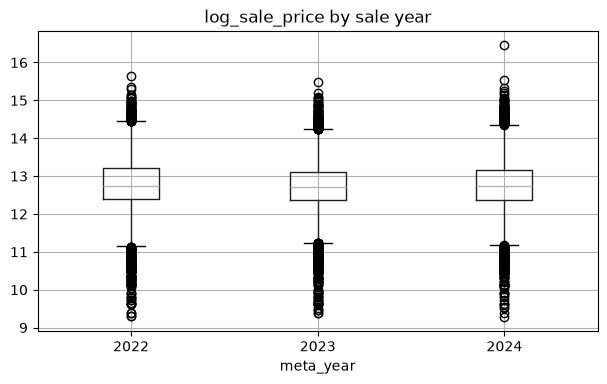

In [19]:
sample.boxplot(column=C.TARGET, by=C.YEAR_COL, figsize=(7, 4))
plt.title('log_sale_price by sale year'); plt.suptitle(''); plt.show()

## Next
1. **Calibrate** `config.NON_ARMS_LENGTH_REASONS` from the section-2 output.
2. Decide **school-rating** handling (~25% missing): impute vs complete-case.
3. Lock any sanity drops from section 6, then move to the modeling notebook (`11_inference_hedonic`).